In [1]:
import sys
!{sys.executable} -m pip install matplotlib

In [2]:
# Imports (torch, numpy, matplotlib, random, re)
import os
import sys
import collections
import matplotlib.pyplot as plt

# Configuration des chemins relatifs
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_PATH = os.path.join(PROJECT_ROOT, "data/fr")

print(f"Racine du projet détectée : {PROJECT_ROOT}")
print(f"Dossier des données : {DATA_PATH}")

# Vérification de la présence des fichiers
files = ["marque_food.txt", "marque_tech.txt"]
for f in files:
    p = os.path.join(DATA_PATH, f)
    print(f"Fichier {f} : {'Trouvé ✓' if os.path.exists(p) else 'INTROUVABLE ✗'}")

Racine du projet détectée : c:\Users\Lenovo\Documents\ProjetVersion1
Dossier des données : c:\Users\Lenovo\Documents\ProjetVersion1\data/fr
Fichier marque_food.txt : Trouvé ✓
Fichier marque_tech.txt : Trouvé ✓


In [3]:
# Dataset de marques françaises (liste de noms + nettoyage)
def analyze_file(filename, encoding='utf-8'):
    path = os.path.join(DATA_PATH, filename)
    with open(path, "r", encoding=encoding) as f:
        lines = [line.strip() for line in f if line.strip()]
    
    total_names = len(lines)
    unique_names = len(set(lines))
    lengths = [len(name) for name in lines]
    avg_length = sum(lengths) / total_names if total_names > 0 else 0
    
    print(f"--- Analyse de {filename} ---")
    print(f"Nombre total de lignes : {total_names}")
    print(f"Noms uniques (sans doublons) : {unique_names}")
    print(f"Longueur moyenne d'un nom : {avg_length:.2f} caractères")
    print(f"Longueur min / max : {min(lengths)} / {max(lengths)} caractères\n")
    return lines

print("Chargement et analyse des datasets bruts...")
lines_fr = analyze_file("marque_food.txt", encoding="utf-8")
lines_ar = analyze_file("marque_tech.txt", encoding="utf-8")

Chargement et analyse des datasets bruts...
--- Analyse de marque_food.txt ---
Nombre total de lignes : 118
Noms uniques (sans doublons) : 118
Longueur moyenne d'un nom : 8.19 caractères
Longueur min / max : 6 / 11 caractères

--- Analyse de marque_tech.txt ---
Nombre total de lignes : 160
Noms uniques (sans doublons) : 160
Longueur moyenne d'un nom : 7.50 caractères
Longueur min / max : 5 / 10 caractères



In [4]:
def get_vocab_info(lines, lang_name):
    all_text = "".join(lines)
    unique_chars = sorted(list(set(all_text)))
    print(f"--- Alphabet/Vocabulaire brut ({lang_name}) ---")
    print(f"Taille du vocabulaire (caractères uniques) : {len(unique_chars)}")
    print(f"Caractères détectés : {' '.join(unique_chars)}\n")
    return unique_chars

vocab_fr = get_vocab_info(lines_fr, "Français")
vocab_ar = get_vocab_info(lines_ar, "Arabe")

--- Alphabet/Vocabulaire brut (Français) ---
Taille du vocabulaire (caractères uniques) : 23
Caractères détectés : a b c d e f g h i k l m n o p q r s t u v x y

--- Alphabet/Vocabulaire brut (Arabe) ---
Taille du vocabulaire (caractères uniques) : 24
Caractères détectés : a b c d e f g h i k l m n o p q r s t u v w x y



In [6]:
import string

def clean_data_fr(lines):
    cleaned = []
    # On garde lettres, chiffres et tiret/espace de base
    allowed = string.ascii_lowercase + string.digits + "- " 
    
    for name in lines:
        name_clean = name.lower().strip()
        # Filtrer les caractères non autorisés si nécessaire
        name_clean = "".join([c for c in name_clean if c in allowed or c in "éèàùçâêîôûëïü"])
        if name_clean:
            cleaned.append(name_clean)
            
    return sorted(list(set(cleaned))) # Suppression définitive des doublons

def clean_data_ar(lines):
    cleaned = []
    for name in lines:
        name_clean = name.strip()
        # Optionnel : vous pouvez ici retirer la voyallisation (Tachkeel) si votre dataset en contient
        if name_clean:
            cleaned.append(name_clean)
    return sorted(list(set(cleaned)))

print("Application du pipeline de nettoyage...")
cleaned_fr = clean_data_fr(lines_fr)
cleaned_ar = clean_data_ar(lines_ar)

print(f"Après nettoyage : {len(cleaned_fr)} noms FR valides et uniques.")
print(f"Après nettoyage : {len(cleaned_ar)} noms AR valides et uniques.")

Application du pipeline de nettoyage...
Après nettoyage : 118 noms FR valides et uniques.
Après nettoyage : 160 noms AR valides et uniques.


In [7]:
def save_clean_dataset(lines, filename):
    output_path = os.path.join(DATA_PATH, filename)
    with open(output_path, "w", encoding="utf-8") as f:
        for name in lines:
            f.write(f"{name}\n")
    print(f"Fichier nettoyé sauvegardé : {output_path} ({os.path.getsize(output_path)} octets)")

print("Sauvegarde des fichiers de données nettoyés...")
# On écrase ou on crée une version propre. Ici on remplace pour alimenter directement votre architecture
save_clean_dataset(cleaned_fr, "dataset_fr.txt")
save_clean_dataset(cleaned_ar, "dataset_ar.txt")
print("\nSprint 1 validé avec succès ! Les données sont prêtes pour l'étape de modélisation (Sprint 2). ✓")

Sauvegarde des fichiers de données nettoyés...
Fichier nettoyé sauvegardé : c:\Users\Lenovo\Documents\ProjetVersion1\data/fr\dataset_fr.txt (1203 octets)
Fichier nettoyé sauvegardé : c:\Users\Lenovo\Documents\ProjetVersion1\data/fr\dataset_ar.txt (1520 octets)

Sprint 1 validé avec succès ! Les données sont prêtes pour l'étape de modélisation (Sprint 2). ✓


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
 
# Vocabulaire : "." = délimiteur début/fin de nom
all_chars  = sorted(set("".join(cleaned_fr)))
VOCAB      = ["."] + all_chars
VOCAB_SIZE = len(VOCAB)
 
stoi = {ch: i for i, ch in enumerate(VOCAB)}
itos = {i: ch for i, ch in enumerate(VOCAB)}
 
print(f"Taille du vocabulaire : {VOCAB_SIZE}")
print(f"Caractères : {VOCAB}")
 

Taille du vocabulaire : 24
Caractères : ['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y']


In [9]:
# -- Construction de la matrice N[i][j] : combien de fois j suit i ? ---------
N = torch.zeros((VOCAB_SIZE, VOCAB_SIZE), dtype=torch.int32)
 
for name in cleaned_fr:
    chars = ["."] + list(name) + ["."]
    for ch1, ch2 in zip(chars, chars[1:]):
        i, j  = stoi.get(ch1, 0), stoi.get(ch2, 0)
        N[i, j] += 1
 
# -- Normalisation avec lissage de Laplace (évite prob = 0) ------------------
P_bigram = (N.float() + 1)                          # +1 = lissage
P_bigram = P_bigram / P_bigram.sum(dim=1, keepdim=True)
 
print(f"Matrice N : {N.shape}")
print(f"Exemple P['.']['a'] = {P_bigram[stoi['.'], stoi.get('a', 1)]:.4f}")
 
# -- Génération avec le bigramme ---------------------------------------------
def generate_bigram(P, itos, stoi, n=10, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    names   = []
    dot_idx = stoi.get(".", 0)
    for _ in range(n * 4):
        chars = []
        idx   = dot_idx
        for _ in range(20):
            probs = P[idx]
            idx   = torch.multinomial(probs, 1).item()
            if idx == dot_idx:
                break
            ch = itos.get(idx, "")
            if not ch:
                break
            chars.append(ch)
        nm = "".join(chars)
        if 3 <= len(nm) <= 12:
            names.append(nm)
        if len(names) >= n:
            break
    return names[:n]
 
print("\nNoms bigramme (seed=42) :", generate_bigram(P_bigram, itos, stoi, n=10, seed=42))
 
# -- Loss bigramme (NLL moyen sur les 100 premiers noms) ---------------------
log_likelihood = 0.0
count          = 0
for name in cleaned_fr[:100]:
    chars = ["."] + list(name) + ["."]
    for ch1, ch2 in zip(chars, chars[1:]):
        i, j            = stoi.get(ch1, 0), stoi.get(ch2, 0)
        log_likelihood += torch.log(P_bigram[i, j]).item()
        count          += 1
 
nll_bigram = -log_likelihood / count
print(f"\nNLL Bigramme moyen : {nll_bigram:.4f}")
 

Matrice N : torch.Size([24, 24])
Exemple P['.']['a'] = 0.0141

Noms bigramme (seed=42) : ['grfl', 'gxtps', 'dxntra', 'guricodgprod', 'frica', 'limyq', 'grix', 'frihstex', 'pix', 'skta']

NLL Bigramme moyen : 2.0520


In [10]:
# Modèle MLP (Embedding + Linear + tanh)
# ============================================================================
 
CONTEXT_SIZE = 3    # nombre de caractères de contexte utilisés
EMBED_DIM    = 16   # dimension de l'espace d'embedding
HIDDEN_DIM   = 64   # neurones de la couche cachée
 
 
class MLP(nn.Module):
    """
    Modèle de langage caractère par caractère.
    Architecture : Embedding → concat → Linear → tanh → Linear (logits)
    Inspiré de Bengio et al. 2003 «A Neural Probabilistic Language Model».
    """
    def __init__(self, vocab_size, embed_dim=EMBED_DIM,
                 context_size=CONTEXT_SIZE, hidden_dim=HIDDEN_DIM):
        super().__init__()
        self.context_size = context_size
        self.emb  = nn.Embedding(vocab_size, embed_dim)
        self.fc1  = nn.Linear(context_size * embed_dim, hidden_dim, bias=True)
        self.fc2  = nn.Linear(hidden_dim, vocab_size, bias=True)
 
    def forward(self, x):
        # x : (batch, context_size) → emb : (batch, context_size * embed_dim)
        e = self.emb(x).view(x.shape[0], -1)
        h = torch.tanh(self.fc1(e))
        return self.fc2(h)   # logits bruts (pas de softmax ici)
 
 
model_mlp = MLP(vocab_size=VOCAB_SIZE)
n_params  = sum(p.numel() for p in model_mlp.parameters())
print(f"Paramètres MLP : {n_params:,}")
 
 

Paramètres MLP : 5,080


In [11]:
#Préparation du dataset + boucle d'entraînement MLP
# ============================================================================
 
def build_dataset(names, stoi, context_size=CONTEXT_SIZE):
    """Transforme une liste de noms en paires (contexte X, cible Y)."""
    X, Y    = [], []
    dot_idx = stoi.get(".", 0)
    for name in names:
        context = [dot_idx] * context_size
        for ch in list(name) + ["."]:
            idx = stoi.get(ch, 0)
            X.append(context[:])
            Y.append(idx)
            context = context[1:] + [idx]
    return torch.tensor(X), torch.tensor(Y)
 
 
X_all, Y_all = build_dataset(cleaned_fr, stoi)
 
# -- Split 80 / 10 / 10 -------------------------------------------------------
n1 = int(0.8 * len(X_all))
n2 = int(0.9 * len(X_all))
X_train, Y_train = X_all[:n1], Y_all[:n1]
X_val,   Y_val   = X_all[n1:n2], Y_all[n1:n2]
X_test,  Y_test  = X_all[n2:], Y_all[n2:]
 
print(f"Train : {len(X_train):,} | Val : {len(X_val):,} | Test : {len(X_test):,}")
 
# -- Boucle d'entraînement ----------------------------------------------------
optimizer     = torch.optim.Adam(model_mlp.parameters(), lr=0.01)
EPOCHS        = 8000
BATCH_SIZE    = 64
EVAL_INTERVAL = 500
 
losses_train = []
losses_val   = []   # liste de (epoch, val_loss)
 
for epoch in range(EPOCHS):
    # Mini-batch aléatoire
    idx_b  = torch.randint(0, len(X_train), (BATCH_SIZE,))
    logits = model_mlp(X_train[idx_b])
    loss   = F.cross_entropy(logits, Y_train[idx_b])
 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
 
    losses_train.append(loss.item())
 
    if epoch % EVAL_INTERVAL == 0 or epoch == EPOCHS - 1:
        model_mlp.eval()
        with torch.no_grad():
            loss_val = F.cross_entropy(model_mlp(X_val), Y_val).item()
        losses_val.append((epoch, loss_val))
        model_mlp.train()
        print(f"Epoch {epoch:5d} | Train : {loss.item():.4f} | Val : {loss_val:.4f}")
 
print("\nEntraînement MLP terminé.")
 
 

Train : 868 | Val : 108 | Test : 109
Epoch     0 | Train : 3.2352 | Val : 3.0504
Epoch   500 | Train : 0.6500 | Val : 2.8135
Epoch  1000 | Train : 0.5898 | Val : 3.1600
Epoch  1500 | Train : 0.5273 | Val : 3.4335
Epoch  2000 | Train : 0.6999 | Val : 3.3728
Epoch  2500 | Train : 0.8046 | Val : 3.7139
Epoch  3000 | Train : 0.5604 | Val : 3.5832
Epoch  3500 | Train : 0.8571 | Val : 3.6995
Epoch  4000 | Train : 0.6158 | Val : 3.9108
Epoch  4500 | Train : 0.5389 | Val : 3.9000
Epoch  5000 | Train : 0.7026 | Val : 3.9251
Epoch  5500 | Train : 0.8815 | Val : 3.8163
Epoch  6000 | Train : 0.7664 | Val : 3.8844
Epoch  6500 | Train : 0.5040 | Val : 3.7695
Epoch  7000 | Train : 0.6503 | Val : 4.3303
Epoch  7500 | Train : 0.7327 | Val : 4.2361
Epoch  7999 | Train : 0.5500 | Val : 4.2026

Entraînement MLP terminé.


In [12]:
#Génération MLP + comparaison Bigramme vs MLP
# ============================================================================
 
@torch.no_grad()
def generate_mlp(model, stoi, itos, context_size=CONTEXT_SIZE,
                 n=10, temperature=1.0, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    model.eval()
    names   = []
    dot_idx = stoi.get(".", 0)
 
    for _ in range(n * 4):
        context = [dot_idx] * context_size
        chars   = []
        for _ in range(20):
            x      = torch.tensor([context])
            logits = model(x) / max(temperature, 1e-5)
            probs  = F.softmax(logits, dim=-1)
            idx    = torch.multinomial(probs, 1).item()
            if idx == dot_idx:
                break
            ch = itos.get(idx, "")
            if not ch:
                break
            chars.append(ch)
            context = context[1:] + [idx]
        nm = "".join(chars)
        if 3 <= len(nm) <= 12:
            names.append(nm)
        if len(names) >= n:
            break
    return names[:n]
 
 
# -- Comparaison visuelle ------------------------------------------------------
bigram_names = generate_bigram(P_bigram, itos, stoi, n=10, seed=42)
mlp_names    = generate_mlp(model_mlp, stoi, itos, n=10, seed=42)
 
print("Noms Bigramme :", bigram_names)
print("Noms MLP      :", mlp_names)
 
# -- NLL final sur le jeu de test ---------------------------------------------
with torch.no_grad():
    nll_mlp = F.cross_entropy(model_mlp(X_test), Y_test).item()
 
print(f"\nRésumé des performances :")
print(f"  Bigramme NLL : {nll_bigram:.4f}")
print(f"  MLP NLL      : {nll_mlp:.4f}")
print(f"  Gain MLP     : {nll_bigram - nll_mlp:+.4f}  "
      f"({'MLP meilleur' if nll_mlp < nll_bigram else 'Bigramme meilleur'})")
 
 

Noms Bigramme : ['grfl', 'gxtps', 'dxntra', 'guricodgprod', 'frica', 'limyq', 'grix', 'frihstex', 'pix', 'skta']
Noms MLP      : ['caterix', 'gustia', 'gastrivalis', 'finealis', 'gaste', 'gustalia', 'naturalis', 'delicalia', 'caterix', 'gaste']

Résumé des performances :
  Bigramme NLL : 2.0520
  MLP NLL      : 5.4075
  Gain MLP     : -3.3555  (Bigramme meilleur)


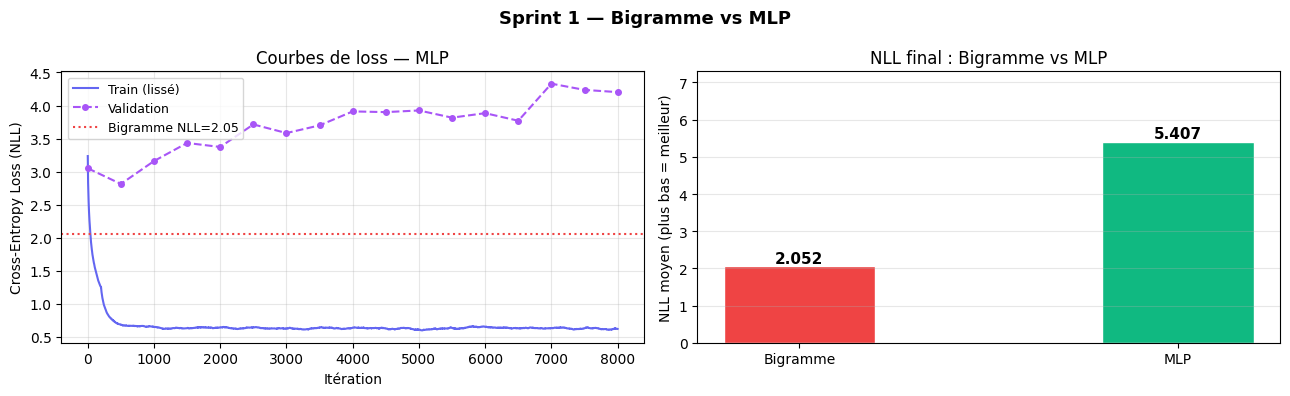

Graphiques sauvegardés → sprint1_loss_curves.png
Sprint 1 complet.


In [13]:
# Visualisation des courbes de loss
# ============================================================================
 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Sprint 1 — Bigramme vs MLP", fontsize=13, fontweight="bold")
 
# -- Courbe gauche : loss d'entraînement + validation MLP --------------------
window   = 200
smoothed = [
    sum(losses_train[max(0, i - window):i + 1]) / min(i + 1, window)
    for i in range(len(losses_train))
]
axes[0].plot(smoothed, color="#6366F1", linewidth=1.5, label="Train (lissé)")
 
val_epochs, val_losses = zip(*losses_val)
axes[0].plot(val_epochs, val_losses, "o--", color="#A855F7",
             linewidth=1.5, markersize=4, label="Validation")
axes[0].axhline(
    nll_bigram, color="#EF4444", linestyle=":", linewidth=1.5,
    label=f"Bigramme NLL={nll_bigram:.2f}",
)
axes[0].set_title("Courbes de loss — MLP")
axes[0].set_xlabel("Itération")
axes[0].set_ylabel("Cross-Entropy Loss (NLL)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
 
# -- Courbe droite : barre comparative NLL final -----------------------------
models_labels = ["Bigramme", "MLP"]
nll_values    = [nll_bigram, nll_mlp]
colors        = ["#EF4444", "#10B981"]
 
bars = axes[1].bar(models_labels, nll_values, color=colors,
                   width=0.4, edgecolor="white", linewidth=1)
for bar, val in zip(bars, nll_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{val:.3f}", ha="center", va="bottom",
        fontweight="bold", fontsize=11,
    )
axes[1].set_title("NLL final : Bigramme vs MLP")
axes[1].set_ylabel("NLL moyen (plus bas = meilleur)")
axes[1].set_ylim(0, max(nll_values) * 1.35)
axes[1].grid(True, alpha=0.3, axis="y")
 
plt.tight_layout()
plt.savefig("sprint1_loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Graphiques sauvegardés → sprint1_loss_curves.png")
print("Sprint 1 complet.")
 